In [12]:
# Bibliothèques utilisées dans ce projet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
années = [2021, 2022, 2023, 2024, 2025]
dfs = []

for année in années:
    path = f"D:\\DATA ESSENTIALS\\analyse_immobiliere_france\\ValeursFoncieres-{année}.txt"
    
    # Lire tout le fichier en chunks et échantillonner au fil de l'eau
    # → pas besoin de connaître le nombre de lignes à l'avance
    chunks = []
    for chunk in pd.read_csv(
        path, sep="|", low_memory=False,
        dtype={'Code departement': str},
        chunksize=100_000
    ):
        chunks.append(chunk.sample(min(6_000, len(chunk)), random_state=42))
    
    df_année = pd.concat(chunks, ignore_index=True)
    
    # Ré-échantillonner à exactement 30 000 si on en a assez
    if len(df_année) > 30_000:
        df_année = df_année.sample(30_000, random_state=42)
    
    df_année["année"] = année
    dfs.append(df_année)
    print(f"{année} ✅ — {len(df_année):,} lignes échantillonnées")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nDonnées brutes : {df_raw.shape[0]:,} lignes, {df_raw.shape[1]} colonnes")

2021 ✅ — 30,000 lignes échantillonnées
2022 ✅ — 30,000 lignes échantillonnées
2023 ✅ — 30,000 lignes échantillonnées
2024 ✅ — 30,000 lignes échantillonnées
2025 ✅ — 30,000 lignes échantillonnées

Données brutes : 150,000 lignes, 44 colonnes


In [ ]:
# schéma pédagogique (pas utile ici pour la suite)
dfs = []  # liste vide

for année in années:
    df_année = pd.read_csv(...)   # chargement avec échantillonnage
    df_année["année"] = année     # ajout colonne année
    dfs.append(df_année)          # ajout à la liste

df_final = pd.concat(dfs, ignore_index=True)  # fusion

ValueError: Invalid file path or buffer object type: <class 'ellipsis'>

In [15]:
#Nettoyage après echantillonnage
#  On garde uniquement les colonnes utiles pour notre analyse
colonnes = [
    'Date mutation', 'Valeur fonciere', 'Commune',
    'Code departement', 'Type local',
    'Surface reelle bati', 'Nombre pieces principales', 'année'
]
df = df_raw[colonnes].copy()

# Convertir la valeur foncière (format français : virgule → point)
df['Valeur fonciere'] = (df['Valeur fonciere']
                         .astype(str)
                         .str.replace(',', '.')
                         .pipe(pd.to_numeric, errors='coerce'))

# Garder uniquement Maisons et Appartements
df = df[df['Type local'].isin(['Maison', 'Appartement'])]

# Supprimer les lignes incomplètes
df = df.dropna(subset=['Valeur fonciere', 'Surface reelle bati'])

# Supprimer les valeurs aberrantes
df = df[df['Surface reelle bati'].between(10, 1000)]
df = df[df['Valeur fonciere'].between(10_000, 5_000_000)]

# Calculer le prix au m²
df['prix_m2'] = df['Valeur fonciere'] / df['Surface reelle bati']
df = df[df['prix_m2'].between(100, 30_000)]

df = df.reset_index(drop=True)

# Sauvegarder le fichier propre
df.to_csv(r"D:\DATA ESSENTIALS\analyse_immobiliere_france\dvf_clean.csv", index=False)

print(f"Données propres : {df.shape[0]:,} lignes")
print(f"Période         : {df['année'].min()} → {df['année'].max()}")
print(f"Types de biens  :\n{df['Type local'].value_counts()}")
print(f"\nPrix m² moyen  : {df['prix_m2'].mean():,.0f} €")
print(f"Prix m² médian : {df['prix_m2'].median():,.0f} €")

Données propres : 43,053 lignes
Période         : 2021 → 2025
Types de biens  :
Type local
Maison         23893
Appartement    19160
Name: count, dtype: int64

Prix m² moyen  : 3,797 €
Prix m² médian : 2,701 €


In [16]:
from scipy import stats

# Stats descriptives globales
print("=== STATISTIQUES GÉNÉRALES ===\n")
print(df['prix_m2'].describe().round(0))

# Intervalles de confiance à 95% par département
print("\n=== INTERVALLES DE CONFIANCE PAR DÉPARTEMENT (95%) ===\n")

resultats = []
for dept, groupe in df.groupby('Code departement'):
    n = len(groupe)
    moyenne = groupe['prix_m2'].mean()
    ic = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=moyenne,
        scale=stats.sem(groupe['prix_m2'])
    )
    resultats.append({
        'département': dept,
        'n_transactions': n,
        'prix_moyen': round(moyenne, 0),
        'IC_bas': round(ic[0], 0),
        'IC_haut': round(ic[1], 0)
    })

ic_df = pd.DataFrame(resultats).sort_values('prix_moyen', ascending=False)

print("Top 10 départements les plus chers :")
print(ic_df.head(10).to_string(index=False))

print("\nTop 10 départements les moins chers :")
print(ic_df.tail(10).to_string(index=False))

ic_df.to_csv(r"D:\DATA ESSENTIALS\analyse_immobiliere_france\stats_departements.csv", index=False)
print("\nStats sauvegardées ✅")

=== STATISTIQUES GÉNÉRALES ===

count    43053.0
mean      3797.0
std       3684.0
min        100.0
25%       1706.0
50%       2701.0
75%       4385.0
max      30000.0
Name: prix_m2, dtype: float64

=== INTERVALLES DE CONFIANCE PAR DÉPARTEMENT (95%) ===

Top 10 départements les plus chers :
département  n_transactions  prix_moyen  IC_bas  IC_haut
         75            1751     10814.0 10626.0  11002.0
         92             787      7800.0  7533.0   8068.0
         94             642      5934.0  5663.0   6205.0
         06            1085      5562.0  5345.0   5779.0
         74             663      5362.0  5090.0   5635.0
         73             359      5180.0  4701.0   5660.0
         93             674      5167.0  4883.0   5450.0
         2A             108      5063.0  4302.0   5825.0
         83            1228      5008.0  4789.0   5227.0
         13            1204      4990.0  4763.0   5217.0

Top 10 départements les moins chers :
département  n_transactions  prix_moyen  I

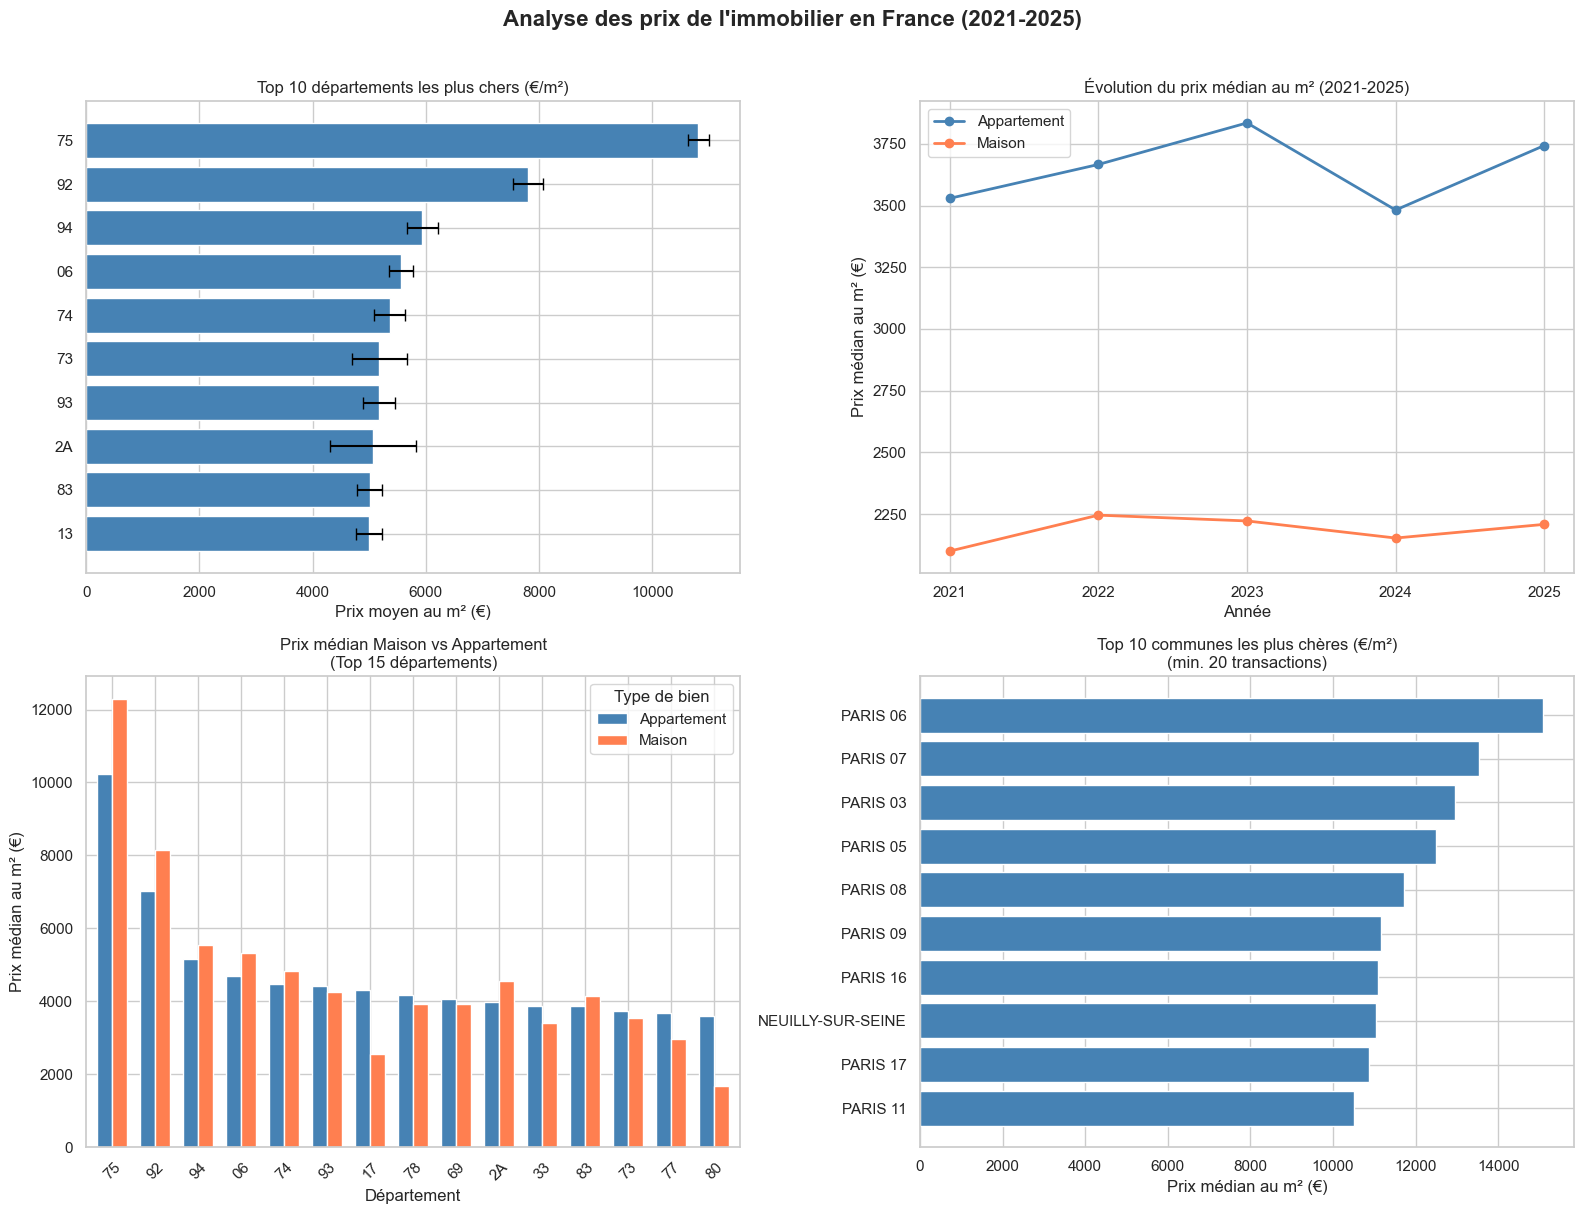

Visualisations sauvegardées


In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse des prix de l'immobilier en France (2021-2025)", fontsize=16, fontweight='bold', y=1.01)

# --- Graphique 1 : Top 10 départements les plus chers ---
ax1 = axes[0, 0]
top10 = ic_df.head(10)
bars = ax1.barh(top10['département'], top10['prix_moyen'], color='steelblue')
ax1.errorbar(
    top10['prix_moyen'], top10['département'],
    xerr=[top10['prix_moyen'] - top10['IC_bas'], top10['IC_haut'] - top10['prix_moyen']],
    fmt='none', color='black', capsize=4
)
ax1.set_title("Top 10 départements les plus chers (€/m²)")
ax1.set_xlabel("Prix moyen au m² (€)")
ax1.invert_yaxis()

# --- Graphique 2 : Évolution des prix sur 5 ans ---
ax2 = axes[0, 1]
evolution = df.groupby(['année', 'Type local'])['prix_m2'].median().reset_index()
for type_bien, couleur in [('Appartement', 'steelblue'), ('Maison', 'coral')]:
    data = evolution[evolution['Type local'] == type_bien]
    ax2.plot(data['année'], data['prix_m2'], marker='o', label=type_bien, color=couleur, linewidth=2)
ax2.set_title("Évolution du prix médian au m² (2021-2025)")
ax2.set_xlabel("Année")
ax2.set_ylabel("Prix médian au m² (€)")
ax2.legend()
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

# --- Graphique 3 : Maison vs Appartement par région ---
ax3 = axes[1, 0]
# Regrouper par grandes régions (2 premiers chiffres du dept)
df['region'] = df['Code departement'].str[:2]
region_type = df.groupby(['region', 'Type local'])['prix_m2'].median().unstack()
region_type = region_type.dropna().sort_values('Appartement', ascending=False).head(15)
region_type.plot(kind='bar', ax=ax3, color=['steelblue', 'coral'], width=0.7)
ax3.set_title("Prix médian Maison vs Appartement\n(Top 15 départements)")
ax3.set_xlabel("Département")
ax3.set_ylabel("Prix médian au m² (€)")
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title="Type de bien")

# --- Graphique 4 : Top 10 communes les plus chères ---
ax4 = axes[1, 1]
top_communes = (df.groupby('Commune')['prix_m2']
                .agg(['median', 'count'])
                .query('count >= 20')
                .sort_values('median', ascending=False)
                .head(10)
                .reset_index())
ax4.barh(top_communes['Commune'], top_communes['median'], color='steelblue')
ax4.set_title("Top 10 communes les plus chères (€/m²)\n(min. 20 transactions)")
ax4.set_xlabel("Prix médian au m² (€)")
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(r"D:\DATA ESSENTIALS\analyse_immobiliere_france\visualisations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualisations sauvegardées")

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# premier test random forest : 0.04 (voir 2 eme test cellule suivante)


# --- Préparation des données ---
# On encode Type local en variable numérique
df['type_encode'] = (df['Type local'] == 'Appartement').astype(int)

features = ['type_encode', 'Surface reelle bati', 'Nombre pieces principales', 'année']
df_ml = df[features + ['prix_m2']].dropna()

X = df_ml[features]
y = df_ml['prix_m2']

# --- Split train / test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entraînement : {len(X_train):,} lignes")
print(f"Test         : {len(X_test):,} lignes")

# --- Entraînement ---
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("\nModèle entraîné")

# --- Évaluation ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n=== RÉSULTATS ===")
print(f"MAE (erreur moyenne) : {mae:,.0f} €/m²")
print(f"R² (qualité du modèle) : {r2:.2f}  (1.0 = parfait)")

# --- Importance des variables ---
print(f"\n=== IMPORTANCE DES VARIABLES ===")
for feature, importance in sorted(zip(features, model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feature:<30} {importance:.2%}")

# --- Exemple de prédiction ---
print(f"\n=== EXEMPLE DE PRÉDICTION ===")
exemple = pd.DataFrame([{
    'type_encode': 1,          # Appartement
    'Surface reelle bati': 60, # 60 m²
    'Nombre pieces principales': 3,
    'année': 2025
}])
prediction = model.predict(exemple)[0]
print(f"Appartement 60m², 3 pièces, 2025 → {prediction:,.0f} €/m²")
print(f"Prix total estimé                → {prediction * 60:,.0f} €")

Entraînement : 34,442 lignes
Test         : 8,611 lignes

Modèle entraîné

=== RÉSULTATS ===
MAE (erreur moyenne) : 2,244 €/m²
R² (qualité du modèle) : 0.04  (1.0 = parfait)

=== IMPORTANCE DES VARIABLES ===
  Surface reelle bati            53.29%
  type_encode                    21.28%
  année                          14.44%
  Nombre pieces principales      10.99%

=== EXEMPLE DE PRÉDICTION ===
Appartement 60m², 3 pièces, 2025 → 3,715 €/m²
Prix total estimé                → 222,905 €


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# --- 1. Préparation des variables (features engineering) ---

# Target encoding : on remplace le département par son prix médian
# C'est plus puissant qu'un simple numéro de département
dept_median = df.groupby('Code departement')['prix_m2'].median()
df['dept_prix_median'] = df['Code departement'].map(dept_median)

# Target encoding de la commune (très puissant car très précis géographiquement)
commune_median = df.groupby('Commune')['prix_m2'].median()
df['commune_prix_median'] = df['Commune'].map(commune_median)

# Encodage du type de bien : Appartement = 1, Maison = 0
df['type_encode'] = (df['Type local'] == 'Appartement').astype(int)

# Nouvelle variable : surface par pièce (ratio utile)
df['surface_par_piece'] = df['Surface reelle bati'] / df['Nombre pieces principales'].replace(0, 1)

# --- 2. Séparation X et y ---
# X = variables explicatives, y = variable cible (prix au m²)
features = [
    'dept_prix_median',    # localisation département
    'commune_prix_median', # localisation commune (plus précis)
    'type_encode',         # maison ou appartement
    'Surface reelle bati', # surface du bien
    'Nombre pieces principales',
    'surface_par_piece',   # ratio surface/pièces
    'année'                # année de la transaction
]

df_ml = df[features + ['prix_m2']].dropna()

X = df_ml[features]
y = np.log(df_ml['prix_m2'])  # log pour stabiliser la distribution des prix

# --- 3. Split Train / Test (80% / 20%) ---
# Le modèle ne verra JAMAIS les données de test pendant l'entraînement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entraînement : {len(X_train):,} lignes")
print(f"Test         : {len(X_test):,} lignes")

# --- 4. Entraînement sur X_train uniquement ---
model = RandomForestRegressor(
    n_estimators=200,  # 200 arbres
    max_depth=15,      # profondeur max pour éviter le surapprentissage
    random_state=42,
    n_jobs=-1          # utilise tous les cœurs du processeur
)
model.fit(X_train, y_train)
print("\nModèle entraîné ✅")

# --- 5. Prédiction sur X_test ---
# On repasse en euros réels avec np.exp (inverse du log)
y_pred = np.exp(model.predict(X_test))
y_test_orig = np.exp(y_test)

# --- 6. Évaluation ---
mae = mean_absolute_error(y_test_orig, y_pred)
r2  = r2_score(y_test_orig, y_pred)

print(f"\n=== ÉVALUATION ===")
print(f"MAE (erreur moyenne absolue) : {mae:,.0f} €/m²")
print(f"R² (variance expliquée)      : {r2:.2f}")

# --- 7. Importance des variables ---
print(f"\n=== IMPORTANCE DES VARIABLES ===")
for feature, importance in sorted(
    zip(features, model.feature_importances_), 
    key=lambda x: -x[1]
):
    print(f"  {feature:<25} {importance:.2%}")

# --- 8. Exemple de prédiction ---
dept_paris = dept_median['75']
commune_paris = commune_median.get('PARIS', dept_paris)

exemple = pd.DataFrame([{
    'dept_prix_median': dept_paris,
    'commune_prix_median': commune_paris,
    'type_encode': 1,
    'Surface reelle bati': 60,
    'Nombre pieces principales': 3,
    'surface_par_piece': 20,
    'année': 2025
}])
prediction = np.exp(model.predict(exemple)[0])
print(f"\n=== EXEMPLE DE PRÉDICTION ===")
print(f"Appartement 60m², 3 pièces, Paris, 2025 → {prediction:,.0f} €/m²")
print(f"Prix total estimé                        → {prediction * 60:,.0f} €")

Entraînement : 34,442 lignes
Test         : 8,611 lignes

Modèle entraîné ✅

=== ÉVALUATION ===
MAE (erreur moyenne absolue) : 1,230 €/m²
R² (variance expliquée)      : 0.44

=== IMPORTANCE DES VARIABLES ===
  commune_prix_median       76.16%
  Surface reelle bati       8.99%
  surface_par_piece         5.32%
  dept_prix_median          4.93%
  année                     2.50%
  type_encode               1.11%
  Nombre pieces principales 0.99%

=== EXEMPLE DE PRÉDICTION ===
Appartement 60m², 3 pièces, Paris, 2025 → 8,060 €/m²
Prix total estimé                        → 483,624 €


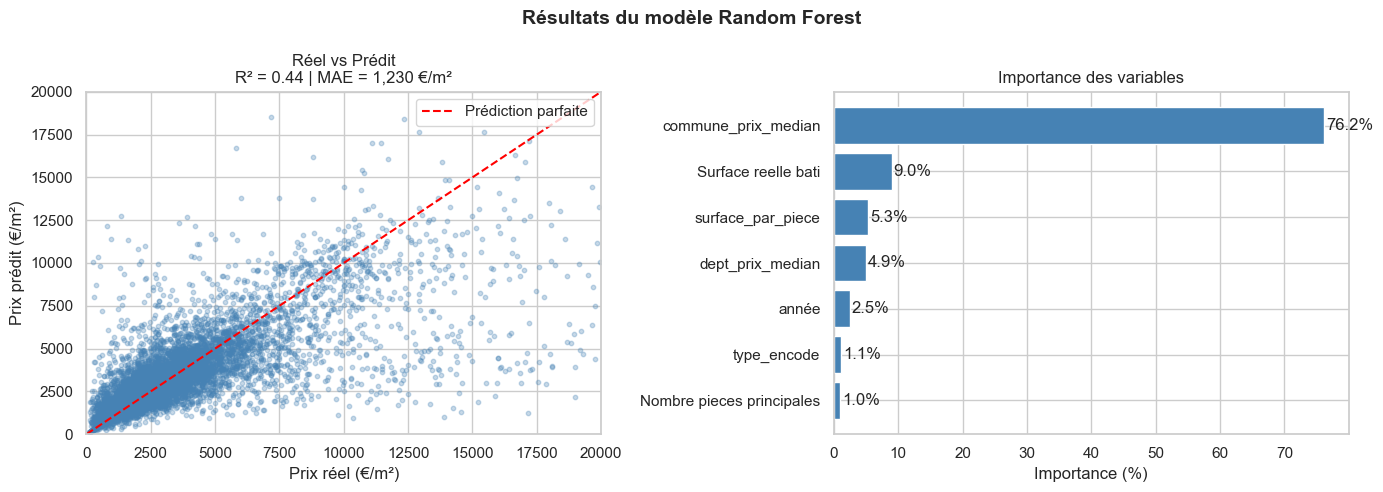

Visualisation ML sauvegardée


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Résultats du modèle Random Forest", fontsize=14, fontweight='bold')

# --- Graphique 1 : Valeurs réelles vs prédites ---
ax1 = axes[0]
ax1.scatter(y_test_orig, y_pred, alpha=0.3, color='steelblue', s=10)
ax1.plot([0, 20000], [0, 20000], color='red', linewidth=1.5, linestyle='--', label='Prédiction parfaite')
ax1.set_xlabel("Prix réel (€/m²)")
ax1.set_ylabel("Prix prédit (€/m²)")
ax1.set_title(f"Réel vs Prédit\nR² = {r2:.2f} | MAE = {mae:,.0f} €/m²")  # dynamique
ax1.set_xlim(0, 20000)
ax1.set_ylim(0, 20000)
ax1.legend()

# --- Graphique 2 : Importance des variables ---
ax2 = axes[1]
importance_df = pd.DataFrame({
    'variable': features,           # dynamique, suit ton modèle
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

ax2.barh(importance_df['variable'], importance_df['importance'] * 100, color='steelblue')
ax2.set_xlabel("Importance (%)")
ax2.set_title("Importance des variables")
for i, v in enumerate(importance_df['importance'] * 100):
    ax2.text(v + 0.3, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.savefig(r"D:\DATA ESSENTIALS\analyse_immobiliere_france\resultats_ml.png", dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation ML sauvegardée")